In [4]:
if "moved_up_dir" not in globals():
    # Code that should run once
    %cd ..
    moved_up_dir = True
else:
    print("Skipping — already executed this session.")

/home/woodbkb2/git/nepo-music


In [ ]:
import json
import sys
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv

from apis import spotify as sp
from data_preprocessing import features_calculator as fc
from tqdm import tqdm

load_dotenv()

True

In [11]:
from importlib import reload
reload(fc)

<module 'base_model.features_calculator' from '/home/woodbkb2/git/nepo-music/base_model/features_calculator.py'>

In [14]:

DATA_DIR = Path('./data')
ARTIST_FULL_DATA = DATA_DIR / "artist_filtered_data"
OUTPUT_FILE = DATA_DIR / "artist_base_features_5_years_only_connections.csv" 

EXCLUDE_LIST = {'[unknown]'}
    

In [15]:
failures = 0
processed = 0
raw_conversions = []

files = [f for f in ARTIST_FULL_DATA.iterdir() if f.suffix == ".jsonl"]

outer_bar = tqdm(files, desc="Files", unit="file", position=0)

for i, file in enumerate(outer_bar):
    try:
        with file.open() as f:
            # new inner bar, always in the same row (position=1)
            inner_bar = tqdm(
                f,
                desc=f"{file.name}",
                unit="row",
                leave=False,
                position=1,
            )

            for raw_artist_work_data in inner_bar:
                try:
                    if raw_artist_work_data == '\n':
                        continue
                    processed += 1
                    artist_work_data = json.loads(raw_artist_work_data)

                    if artist_work_data["artist_name"] in EXCLUDE_LIST:
                        continue

                    calculated_metrics = fc.compute_mb_artist_early_features(
                        artist_work_data,
                    )
                    raw_conversions.append(calculated_metrics)

                    if processed % 1000 == 0:
                        # update the outer bar info instead of printing a new line
                        outer_bar.set_postfix(
                            processed=processed,
                            failures=failures,
                        )

                except Exception as e:
                    failures += 1
                    outer_bar.set_postfix(
                        processed=processed,
                        failures=failures,
                        last_error="row",
                    )
                    print(f'failed with: {e}, line was: {raw_artist_work_data}')

            inner_bar.close()

    except Exception as e:
        failures += 1
        outer_bar.set_postfix(
            processed=processed,
            failures=failures,
            last_error=f"file {file.name}",
        )

outer_bar.close()


Files:   0%|          | 0/194 [00:00<?, ?file/s]

Files: 100%|██████████| 194/194 [39:10<00:00, 12.12s/file, failures=0, processed=98000]


In [17]:
df = pd.DataFrame(raw_conversions)
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,None,48657,393.969613,0.926134,1.916525,700.010758,...,jazz,"bebop, jazz, blues, rock, big band, jazz-funk,...",United States,Duquesne,123.504449,1902.0,1900.0,0.854117,arranger,"arranger, composer, instrument, performer, voc..."
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,None,370,4.629753,78.639566,0.019246,7.029738,...,classical,"classical, opera",France,Saint-Mandé,79.917864,1946.0,1940.0,0.568334,arranger,"arranger, composer, conductor, instrument, orc..."
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,None,2,0.300865,0.000000,NaN,NaN,...,None,,Netherlands,Aruba,6.647502,2019.0,2010.0,0.000343,writer,writer
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,None,6,0.376935,395.400000,0.002327,0.850016,...,None,,Wales,None,15.917864,2010.0,2010.0,0.000003,vocal,vocal
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,None,24,0.986940,300.695652,0.003116,1.138195,...,jasrac-no-iswc,"jasrac, jasrac-no-iswc",Sweden,Gothenburg,24.317591,2001.0,2000.0,0.001567,composer,"composer, lyricist, vocal"


In [18]:
# we need debut_date to do anything
df = df[df['debut_date'].notnull()]
df.shape

(98212, 40)

In [19]:
df.columns

Index(['artist_mbid', 'artist_name', 'window_years', 'debut_date',
       'window_cutoff_date', 'releases_total', 'releases_per_year',
       'avg_days_between_releases', 'release_velocity_releases_per_day',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'unique_collaborator_count',
       'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label',
       'all_labels_str', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'all_genres_str',
       'artist_country', 'artist_region_city', 'years_active', 'debut_year',
       'debut_decade', 'recency_index', 'primary_role', 'all_roles_str'],
      dtype='object')

In [20]:
for col in ["debut_date", "window_cutoff_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce").dt.date

In [21]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,NaT,48657,393.969613,0.926134,1.916525,700.010758,...,jazz,"bebop, jazz, blues, rock, big band, jazz-funk,...",United States,Duquesne,123.504449,1902.0,1900.0,0.854117,arranger,"arranger, composer, instrument, performer, voc..."
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,NaT,370,4.629753,78.639566,0.019246,7.029738,...,classical,"classical, opera",France,Saint-Mandé,79.917864,1946.0,1940.0,0.568334,arranger,"arranger, composer, conductor, instrument, orc..."
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,NaT,2,0.300865,0.000000,NaN,NaN,...,None,,Netherlands,Aruba,6.647502,2019.0,2010.0,0.000343,writer,writer
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,NaT,6,0.376935,395.400000,0.002327,0.850016,...,None,,Wales,None,15.917864,2010.0,2010.0,0.000003,vocal,vocal
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,NaT,24,0.986940,300.695652,0.003116,1.138195,...,jasrac-no-iswc,"jasrac, jasrac-no-iswc",Sweden,Gothenburg,24.317591,2001.0,2000.0,0.001567,composer,"composer, lyricist, vocal"


In [22]:
numeric_cols = [
    "years_active", "debut_year", "debut_decade", "recency_index",
    "releases_total", "releases_per_year", "avg_days_between_releases",
    "release_velocity_releases_per_day", "release_velocity_releases_per_year",
    "gap_median_days", "gap_std_days", "max_dry_spell_days",
    "front_loading_index",
    "tracks_total", "collab_track_rate", "unique_collaborator_count",
    "label_diversity_count", "label_churn", "label_hhi",
    "duration_ms_mean", "duration_ms_median",
    "duration_ms_min", "duration_ms_max",
    "remix_rate", "acoustic_rate",
    "genre_count", "genre_entropy",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [23]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,NaT,48657,393.969613,0.926134,1.916525,700.010758,...,jazz,"bebop, jazz, blues, rock, big band, jazz-funk,...",United States,Duquesne,123.504449,1902.0,1900.0,0.854117,arranger,"arranger, composer, instrument, performer, voc..."
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,NaT,370,4.629753,78.639566,0.019246,7.029738,...,classical,"classical, opera",France,Saint-Mandé,79.917864,1946.0,1940.0,0.568334,arranger,"arranger, composer, conductor, instrument, orc..."
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,NaT,2,0.300865,0.000000,NaN,NaN,...,None,,Netherlands,Aruba,6.647502,2019.0,2010.0,0.000343,writer,writer
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,NaT,6,0.376935,395.400000,0.002327,0.850016,...,None,,Wales,None,15.917864,2010.0,2010.0,0.000003,vocal,vocal
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,NaT,24,0.986940,300.695652,0.003116,1.138195,...,jasrac-no-iswc,"jasrac, jasrac-no-iswc",Sweden,Gothenburg,24.317591,2001.0,2000.0,0.001567,composer,"composer, lyricist, vocal"


In [24]:
if "tracks_total" in df.columns:
        df["missing_recordings_flag"] = df["tracks_total"].isna() | (df["tracks_total"] == 0)

# Genres
if "genre_count" in df.columns:
    df["missing_genres_flag"] = df["genre_count"].isna() | (df["genre_count"] == 0)

# Labels
if "label_diversity_count" in df.columns:
    df["missing_labels_flag"] = df["label_diversity_count"].isna() | (df["label_diversity_count"] == 0)

# Cadence (no releases in early window)
if "releases_total" in df.columns:
    df["missing_releases_flag"] = df["releases_total"].isna() | (df["releases_total"] == 0)

# Recency index (optional: explicit missing flag)
if "recency_index" in df.columns:
    df["recency_index_missing_flag"] = df["recency_index"].isna()

In [25]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,debut_year,debut_decade,recency_index,primary_role,all_roles_str,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,NaT,48657,393.969613,0.926134,1.916525,700.010758,...,1902.0,1900.0,0.854117,arranger,"arranger, composer, instrument, performer, voc...",False,False,False,False,False
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,NaT,370,4.629753,78.639566,0.019246,7.029738,...,1946.0,1940.0,0.568334,arranger,"arranger, composer, conductor, instrument, orc...",False,False,False,False,False
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,NaT,2,0.300865,0.000000,NaN,NaN,...,2019.0,2010.0,0.000343,writer,writer,False,True,False,False,False
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,NaT,6,0.376935,395.400000,0.002327,0.850016,...,2010.0,2010.0,0.000003,vocal,vocal,False,True,False,False,False
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,NaT,24,0.986940,300.695652,0.003116,1.138195,...,2001.0,2000.0,0.001567,composer,"composer, lyricist, vocal",False,False,False,False,False


In [26]:
zero_fill_cols = [
    "releases_total",
    "tracks_total",
    "unique_collaborator_count",
    "label_diversity_count",
    "label_churn",
    "genre_count",
]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [27]:
none_ok_cols = [
    "releases_per_year",
    "avg_days_between_releases",
    "release_velocity_releases_per_day",
    "release_velocity_releases_per_year",
    "gap_median_days",
    "gap_std_days",
    "max_dry_spell_days",
    "front_loading_index",
    "collab_track_rate",
    "label_hhi",
    "duration_ms_mean",
    "duration_ms_median",
    "duration_ms_min",
    "duration_ms_max",
    "remix_rate",
    "acoustic_rate",
    "genre_entropy",
    "years_active",
    "recency_index",
]
for col in none_ok_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [28]:
if "artist_country" in df.columns:
    df["artist_country"] = df["artist_country"].fillna("unknown")
    df["artist_country"] = df["artist_country"].replace("", "unknown")

if "artist_region_city" in df.columns:
    df["artist_region_city"] = df["artist_region_city"].fillna("unknown")
    df["artist_region_city"] = df["artist_region_city"].replace("", "unknown")

# country/region known flags can be recomputed from cleaned values
if "artist_country" in df.columns:
    df["location_country_known"] = df["artist_country"].ne("unknown")
if "artist_region_city" in df.columns:
    df["location_region_city_known"] = df["artist_region_city"].ne("unknown")

# Label / genre categories
if "primary_label" in df.columns:
    df["primary_label"] = df["primary_label"].fillna("unknown")
    df["primary_label"] = df["primary_label"].replace("", "unknown")

if "primary_genre" in df.columns:
    df["primary_genre"] = df["primary_genre"].fillna("unknown")
    df["primary_genre"] = df["primary_genre"].replace("", "unknown")

In [29]:
for col in ["releases_total", "tracks_total", "unique_collaborator_count",
            "label_diversity_count", "label_churn", "genre_count"]:
    if col in df.columns:
        df[col] = df[col].astype(int)


In [30]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,recency_index,primary_role,all_roles_str,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag,location_country_known,location_region_city_known
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,NaT,48657,393.969613,0.926134,1.916525,700.010758,...,0.854117,arranger,"arranger, composer, instrument, performer, voc...",False,False,False,False,False,True,True
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,NaT,370,4.629753,78.639566,0.019246,7.029738,...,0.568334,arranger,"arranger, composer, conductor, instrument, orc...",False,False,False,False,False,True,True
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,NaT,2,0.300865,0.000000,0.000000,0.000000,...,0.000343,writer,writer,False,True,False,False,False,True,True
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,NaT,6,0.376935,395.400000,0.002327,0.850016,...,0.000003,vocal,vocal,False,True,False,False,False,True,False
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,NaT,24,0.986940,300.695652,0.003116,1.138195,...,0.001567,composer,"composer, lyricist, vocal",False,False,False,False,False,True,True


In [31]:
df.shape

(98212, 47)

In [32]:
artist_metrics = {}
with open('data/artist_to_metrics_map.jsonl') as f:
    for l in f:
        d = json.loads(l)
        artist_metrics[d['artist_mbid']] = {'followers':d['followers'], 'popularity': d['popularity']}

In [33]:
artist_metrics['00003549-92af-4273-9eb4-0a75879da303']

{'followers': 4971, 'popularity': 24}

In [34]:
valid_mbids = set(artist_metrics.keys())
df = df[df["artist_mbid"].isin(valid_mbids)]
df.shape

(98084, 47)

In [35]:
df['popularity'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['popularity'])
df['followers'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['followers'])
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,all_roles_str,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag,location_country_known,location_region_city_known,popularity,followers
0,5d7df598-bb80-4d73-a6f8-9ed1a4374052,Earl Hines,None,1902-06-01,NaT,48657,393.969613,0.926134,1.916525,700.010758,...,"arranger, composer, instrument, performer, voc...",False,False,False,False,False,True,True,35,33057
1,5d7e4d03-5c69-4159-b2b7-092dddbcb09f,Jean‐Michel Defaye,None,1946-01-01,NaT,370,4.629753,78.639566,0.019246,7.029738,...,"arranger, composer, conductor, instrument, orc...",False,False,False,False,False,True,True,6,173
2,5d7f1460-e2a6-4fc0-86df-6f9a8d129416,DIAMANTA,None,2019-04-10,NaT,2,0.300865,0.000000,0.000000,0.000000,...,writer,False,True,False,False,False,True,True,1,127
3,5d7f1a01-e08b-44dd-9cab-5a885487250c,Fflur Wyn,None,2010-01-01,NaT,6,0.376935,395.400000,0.002327,0.850016,...,vocal,False,True,False,False,False,True,False,4,74
4,5d7f1f89-4df0-4754-b739-55ab8b9c8b31,Frida Sundemo,None,2001-08-08,NaT,24,0.986940,300.695652,0.003116,1.138195,...,"composer, lyricist, vocal",False,False,False,False,False,True,True,0,167


In [36]:
df['window_years'].max()

nan

In [37]:
df[df['unique_collaborator_count'] > 0].shape

(98049, 49)

In [38]:
df.to_csv('data/artist_base_features_5_years_only_collab.csv', index=False)

<Axes: >

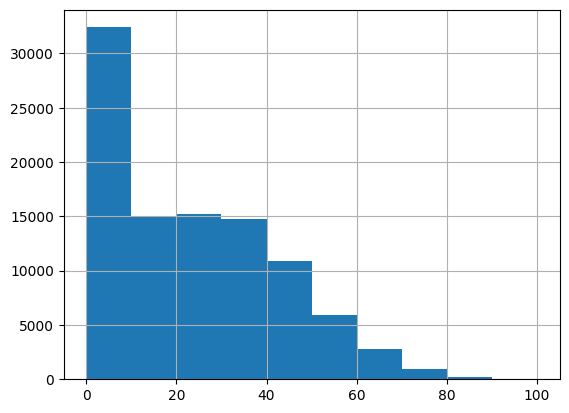

In [39]:
df['popularity'].hist()

In [40]:
df[df['artist_name'] == "Taylor Swift"]

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,all_roles_str,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag,location_country_known,location_region_city_known,popularity,followers
32310,20244d07-534f-4eff-b4d4-930878889970,Taylor Swift,None,1928-01-01,NaT,15126,154.474249,2.364826,0.878852,321.000516,...,"composer, editor, instrument, lyricist, perfor...",False,False,False,False,False,True,True,100,147013844


In [5]:
import pandas as pd

In [36]:
df = pd.read_csv('./data/artist_base_features_5_years_only_collab.csv')

In [37]:
df["unique_collaborator_count"].value_counts()

unique_collaborator_count
2      23277
1      20140
3      12583
4       8644
5       5526
       ...  
89         1
124        1
112        1
179        1
123        1
Name: count, Length: 118, dtype: int64

In [38]:
df.shape

(86762, 40)

In [20]:
import json

In [25]:
with open('./data/artist_filtered_data/filtered_artist_data_part-0001.jsonl')as f:
    for l in f:
        l = json.loads(l)
        print(json.dumps(l["works"], indent=4))
        break

[
    {
        "id": 14544261,
        "name": "Red Kite",
        "first_release_date": "2022-11-11",
        "genres": [],
        "collaborators": [
            {
                "mbid": "60dea8d6-f194-4d94-b718-52430756bab9",
                "name": "Joseph Watt",
                "roles": [
                    "composer"
                ]
            },
            {
                "mbid": "000099ff-90b9-4cb8-a062-49067ce1f452",
                "name": "Odokuro",
                "roles": [
                    "composer"
                ]
            }
        ]
    },
    {
        "id": 14632641,
        "name": "Last Man on Earth",
        "first_release_date": "2024-01-12",
        "genres": [],
        "collaborators": [
            {
                "mbid": "60dea8d6-f194-4d94-b718-52430756bab9",
                "name": "Joseph Watt",
                "roles": [
                    "composer"
                ]
            },
            {
                "mbid": "000099ff-90b

In [7]:
df.shape

(98588, 41)

In [9]:
df.columns

Index(['Unnamed: 0', 'artist_mbid', 'artist_name', 'window_years',
       'debut_date', 'window_cutoff_date', 'releases_total',
       'releases_per_year', 'avg_days_between_releases',
       'release_velocity_releases_per_day',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'unique_collaborator_count',
       'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label',
       'all_labels_str', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'all_genres_str',
       'artist_country', 'artist_region_city', 'years_active', 'debut_year',
       'debut_decade', 'recency_index', 'primary_role', 'all_roles_str'],
      dtype='object')

In [14]:
df = df[df['unique_collaborator_count'] > 0]
df.shape

(97376, 41)

In [17]:
df.to_csv('./data/artist_base_features_5_years_only_collab.csv')